In [2]:
import pandas as pd
df =  pd.read_csv('startup_funding.csv')
print(df.head())
print(df.info())
print(df.describe())

   Sr No Date dd/mm/yyyy                  Startup Name    Industry Vertical  \
0      1      09/01/2020                        BYJU’S               E-Tech   
1      2      13/01/2020                        Shuttl       Transportation   
2      3      09/01/2020                     Mamaearth           E-commerce   
3      4      02/01/2020  https://www.wealthbucket.in/              FinTech   
4      5      02/01/2020                        Fashor  Fashion and Apparel   

                             SubVertical City  Location  \
0                             E-learning      Bengaluru   
1              App based shuttle service        Gurgaon   
2  Retailer of baby and toddler products      Bengaluru   
3                      Online Investment      New Delhi   
4            Embroiled Clothes For Women         Mumbai   

              Investors Name       InvestmentnType Amount in USD Remarks  
0    Tiger Global Management  Private Equity Round  20,00,00,000     NaN  
1  Susquehanna Growt

In [3]:
print(df['Date dd/mm/yyyy'].min())
print(df['Date dd/mm/yyyy'].max())

01/01/2016
\\xc2\\xa010/7/2015


In [4]:
print(df.isnull().sum())
print(df['Industry Vertical'].value_counts().head(10))
print(df['City  Location'].value_counts().head(10))

Sr No                   0
Date dd/mm/yyyy         0
Startup Name            0
Industry Vertical     171
SubVertical           936
City  Location        180
Investors Name         24
InvestmentnType         4
Amount in USD         960
Remarks              2625
dtype: int64
Industry Vertical
Consumer Internet    941
Technology           478
eCommerce            186
Healthcare            70
Finance               62
ECommerce             61
Logistics             32
E-Commerce            29
Education             24
Food & Beverage       23
Name: count, dtype: int64
City  Location
Bangalore    700
Mumbai       567
New Delhi    421
Gurgaon      287
Bengaluru    141
Pune         105
Hyderabad     99
Chennai       97
Noida         92
Gurugram      50
Name: count, dtype: int64


In [5]:
# Fix city names
df['City  Location'] = df['City  Location'].str.strip()
df['City  Location'] = df['City  Location'].replace({
    'Bengaluru': 'Bangalore',
    'Gurugram': 'Gurgaon',
    'New Delhi': 'Delhi',
    'NCR': 'Delhi'
})

# Fix industry names
df['Industry Vertical'] = df['Industry Vertical'].str.strip()
df['Industry Vertical'] = df['Industry Vertical'].replace({
    'eCommerce': 'E-Commerce',
    'ECommerce': 'E-Commerce',
    'Ecommerce': 'E-Commerce',
    'FinTech': 'Finance',
    'Fintech': 'Finance'
})

# Clean Amount column
df['Amount in USD'] = df['Amount in USD'].str.replace(',', '').str.strip()
df['Amount in USD'] = pd.to_numeric(df['Amount in USD'], errors='coerce')

# Verify
print(df['City  Location'].value_counts().head(10))
print(df['Industry Vertical'].value_counts().head(10))
print(df['Amount in USD'].describe())

City  Location
Bangalore    841
Mumbai       567
Delhi        455
Gurgaon      337
Pune         105
Hyderabad     99
Chennai       97
Noida         92
Ahmedabad     38
Jaipur        30
Name: count, dtype: int64
Industry Vertical
Consumer Internet    941
Technology           478
E-Commerce           284
Finance               72
Healthcare            70
Logistics             32
Education             24
Food & Beverage       23
Ed-Tech               14
E-commerce            12
Name: count, dtype: int64
count    2.065000e+03
mean     1.842990e+07
std      1.213734e+08
min      1.600000e+04
25%      4.700000e+05
50%      1.700000e+06
75%      8.000000e+06
max      3.900000e+09
Name: Amount in USD, dtype: float64


In [6]:
df['Industry Vertical'] = df['Industry Vertical'].replace({
    'E-commerce': 'E-Commerce',
    'Ed-Tech': 'Education',
    'EdTech': 'Education',
    'E-Tech': 'Education',
    'HealthCare': 'Healthcare',
    'health care': 'Healthcare',
    'Fin-Tech': 'Finance',
})

print(df['Industry Vertical'].value_counts().head(15))

Industry Vertical
Consumer Internet            941
Technology                   478
E-Commerce                   296
Finance                       78
Healthcare                    70
Education                     42
Logistics                     32
Food & Beverage               23
IT                             8
Real Estate                    6
Others                         6
Food and Beverage              6
Online Education Platform      5
Online Food Delivery           5
Health and Wellness            5
Name: count, dtype: int64


In [7]:
print(df.nlargest(5, 'Amount in USD')[['Startup Name', 'Amount in USD', 'Industry Vertical']])

         Startup Name  Amount in USD Industry Vertical
60   Rapido Bike Taxi   3.900000e+09    Transportation
651          Flipkart   2.500000e+09        E-Commerce
830             Paytm   1.400000e+09        E-Commerce
966          Flipkart   1.400000e+09        E-Commerce
31              Paytm   1.000000e+09           Finance


In [8]:
# Flag suspicious amounts - anything over $500M needs checking
suspicious = df[df['Amount in USD'] > 500000000][['Startup Name', 'Amount in USD', 'InvestmentnType']]
print(suspicious)

          Startup Name  Amount in USD InvestmentnType
31               Paytm   1.000000e+09   Funding Round
33               Udaan   5.850000e+08        Series D
60    Rapido Bike Taxi   3.900000e+09        Series B
188         True North   6.000000e+08  Private Equity
651           Flipkart   2.500000e+09  Private Equity
830              Paytm   1.400000e+09  Private Equity
966           Flipkart   1.400000e+09  Private Equity
2459             Paytm   6.800000e+08  Private Equity
2648      Flipkart.com   7.000000e+08  Private Equity


In [9]:
# Drop Rapido outlier
df = df[df['Startup Name'] != 'Rapido Bike Taxi']

# Verify it's gone
print(f"Dataset now has {len(df)} rows")
print(df.nlargest(3, 'Amount in USD')[['Startup Name', 'Amount in USD']])

Dataset now has 3043 rows
    Startup Name  Amount in USD
651     Flipkart   2.500000e+09
830        Paytm   1.400000e+09
966     Flipkart   1.400000e+09


In [10]:
import matplotlib.pyplot as plt

# First convert date column properly
df['Date dd/mm/yyyy'] = pd.to_datetime(df['Date dd/mm/yyyy'], dayfirst=True, errors='coerce')
df['Year'] = df['Date dd/mm/yyyy'].dt.year
df['Month'] = df['Date dd/mm/yyyy'].dt.month

# 1. Number of deals per year
deals_per_year = df.groupby('Year').size()
print("Deals per year:")
print(deals_per_year)

# 2. Total funding per year
funding_per_year = df.groupby('Year')['Amount in USD'].sum()
print("\nTotal funding per year (USD):")
print(funding_per_year)

# 3. Top 10 industries by number of deals
top_industries = df['Industry Vertical'].value_counts().head(10)
print("\nTop industries by deals:")
print(top_industries)

# 4. Top 5 cities by deals
top_cities = df['City  Location'].value_counts().head(5)
print("\nTop cities:")
print(top_cities)

Deals per year:
Year
2015.0    929
2016.0    993
2017.0    687
2018.0    309
2019.0    110
2020.0      7
dtype: int64

Total funding per year (USD):
Year
2015.0    8.597207e+09
2016.0    3.828089e+09
2017.0    1.042931e+10
2018.0    5.116118e+09
2019.0    5.786577e+09
2020.0    3.902073e+08
Name: Amount in USD, dtype: float64

Top industries by deals:
Industry Vertical
Consumer Internet    941
Technology           478
E-Commerce           296
Finance               78
Healthcare            70
Education             42
Logistics             32
Food & Beverage       23
IT                     8
Real Estate            6
Name: count, dtype: int64

Top cities:
City  Location
Bangalore    840
Mumbai       567
Delhi        455
Gurgaon      337
Pune         105
Name: count, dtype: int64


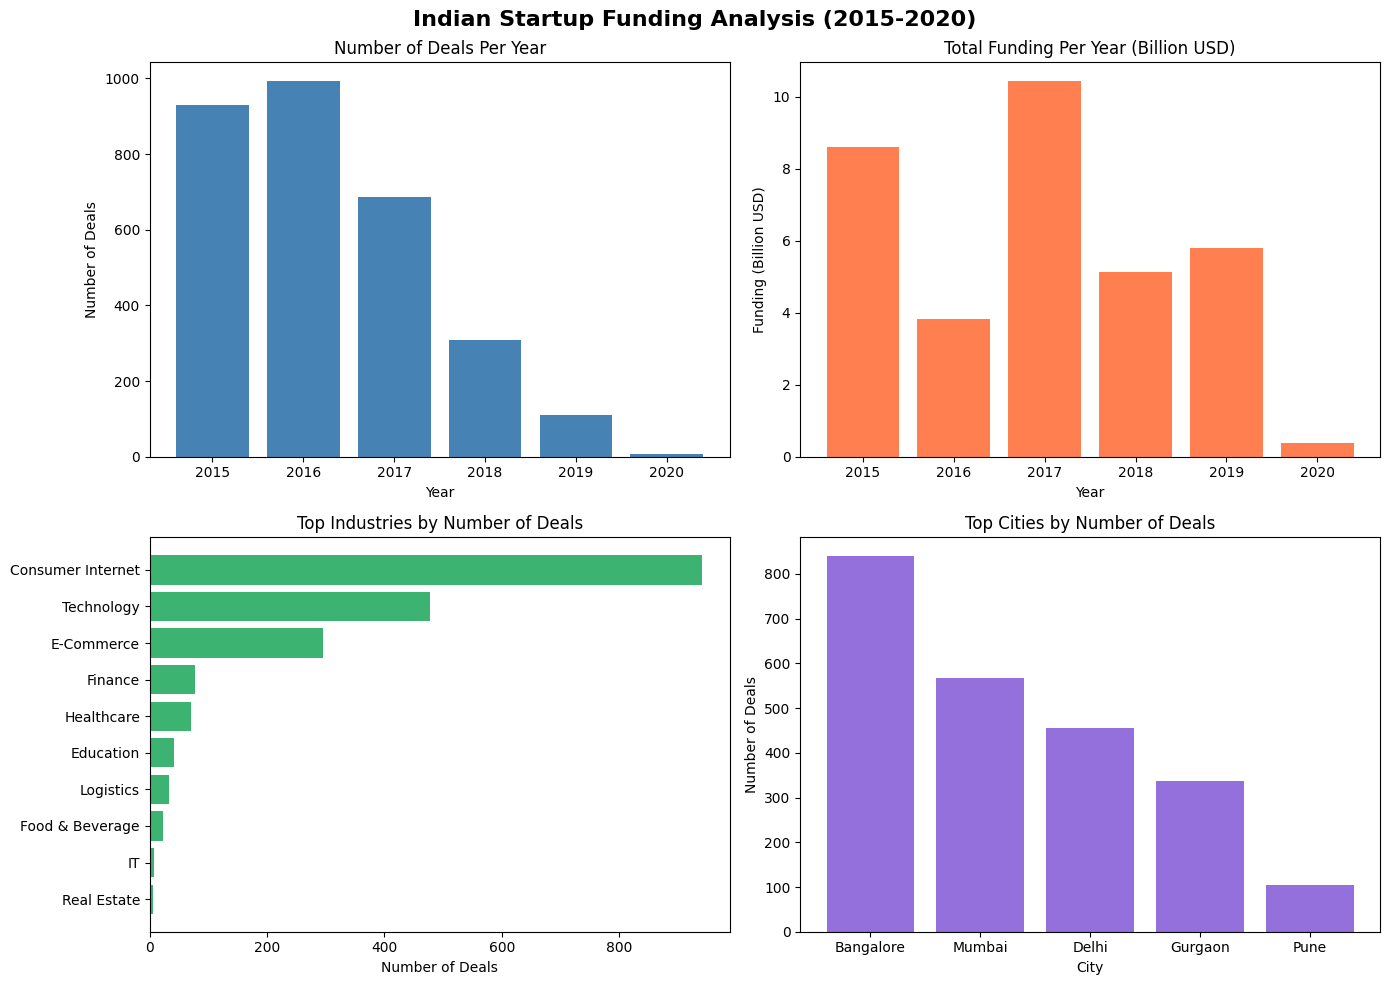

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Indian Startup Funding Analysis (2015-2020)', fontsize=16, fontweight='bold')

# 1. Deals per year
axes[0,0].bar(deals_per_year.index, deals_per_year.values, color='steelblue')
axes[0,0].set_title('Number of Deals Per Year')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Number of Deals')

# 2. Funding per year
axes[0,1].bar(funding_per_year.index, funding_per_year.values / 1e9, color='coral')
axes[0,1].set_title('Total Funding Per Year (Billion USD)')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Funding (Billion USD)')

# 3. Top industries
axes[1,0].barh(top_industries.index[::-1], top_industries.values[::-1], color='mediumseagreen')
axes[1,0].set_title('Top Industries by Number of Deals')
axes[1,0].set_xlabel('Number of Deals')

# 4. Top cities
axes[1,1].bar(top_cities.index, top_cities.values, color='mediumpurple')
axes[1,1].set_title('Top Cities by Number of Deals')
axes[1,1].set_xlabel('City')
axes[1,1].set_ylabel('Number of Deals')

plt.tight_layout()
plt.savefig('startup_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Average deal size per year - this tells the real story
avg_deal = df.groupby('Year')['Amount in USD'].mean()
print("Average deal size per year:")
print(avg_deal)

# Average deal size by industry
avg_by_industry = df.groupby('Industry Vertical')['Amount in USD'].mean().sort_values(ascending=False).head(10)
print("\nAverage deal size by industry (USD):")
print(avg_by_industry)

# Investment type breakdown
print("\nInvestment types:")
print(df['InvestmentnType'].value_counts().head(10))

Average deal size per year:
Year
2015.0    1.339129e+07
2016.0    6.532574e+06
2017.0    2.287129e+07
2018.0    1.937924e+07
2019.0    5.618035e+07
2020.0    5.574389e+07
Name: Amount in USD, dtype: float64

Average deal size by industry (USD):
Industry Vertical
E-Commerce & M-Commerce platform      680000000.0
Ecommerce Marketplace                 500000000.0
Car Aggregator & Retail Mobile App    500000000.0
Cab Aggregator                        400000000.0
Online Marketplace                    350071500.0
Automation                            300000000.0
B2B                                   293500000.0
B2B Platform                          225000000.0
Cab rental Mobile app                 225000000.0
Online Classifieds                    150000000.0
Name: Amount in USD, dtype: float64

Investment types:
InvestmentnType
Private Equity          1356
Seed Funding            1355
Seed/ Angel Funding       60
Seed / Angel Funding      47
Seed\\nFunding            30
Debt Funding         

In [13]:
# Fix investment types
df['InvestmentnType'] = df['InvestmentnType'].str.strip()
df['InvestmentnType'] = df['InvestmentnType'].replace({
    'Seed/ Angel Funding': 'Seed Funding',
    'Seed / Angel Funding': 'Seed Funding',
    'Seed\\nFunding': 'Seed Funding',
    'Seed/Angel Funding': 'Seed Funding',
    'Angel / Seed Funding': 'Seed Funding',
    'angel': 'Angel Funding',
    'Angel': 'Angel Funding',
})

# Average deal size by MAIN industry (not subvertical)
avg_by_industry = df.groupby('Industry Vertical')['Amount in USD'].mean().sort_values(ascending=False).head(10)
print("Average deal size by industry:")
print(avg_by_industry)

# Investment type cleaned
print("\nCleaned investment types:")
print(df['InvestmentnType'].value_counts().head(10))

# The most interesting comparison - deals vs money by industry
industry_summary = df.groupby('Industry Vertical').agg(
    total_deals=('Startup Name', 'count'),
    total_funding=('Amount in USD', 'sum'),
    avg_deal=('Amount in USD', 'mean')
).sort_values('total_deals', ascending=False).head(10)

print("\nIndustry summary:")
print(industry_summary)

Average deal size by industry:
Industry Vertical
E-Commerce & M-Commerce platform      680000000.0
Ecommerce Marketplace                 500000000.0
Car Aggregator & Retail Mobile App    500000000.0
Cab Aggregator                        400000000.0
Online Marketplace                    350071500.0
Automation                            300000000.0
B2B                                   293500000.0
B2B Platform                          225000000.0
Cab rental Mobile app                 225000000.0
Online Classifieds                    150000000.0
Name: Amount in USD, dtype: float64

Cleaned investment types:
InvestmentnType
Seed Funding            1493
Private Equity          1356
Seed\\nFunding            30
Debt Funding              25
Series A                  24
Series B                  19
Series C                  14
Series D                  12
Seed Round                 7
Private Equity Round       4
Name: count, dtype: int64

Industry summary:
                   total_deals  total

In [14]:
df['InvestmentnType'] = df['InvestmentnType'].replace({
    'Seed\\nFunding': 'Seed Funding',
    'Seed Round': 'Seed Funding',
    'Private Equity Round': 'Private Equity',
    'Funding Round': 'Private Equity'
})

print(df['InvestmentnType'].value_counts().head(8))

InvestmentnType
Seed Funding      1500
Private Equity    1361
Seed\\nFunding      30
Debt Funding        25
Series A            24
Series B            19
Series C            14
Series D            12
Name: count, dtype: int64


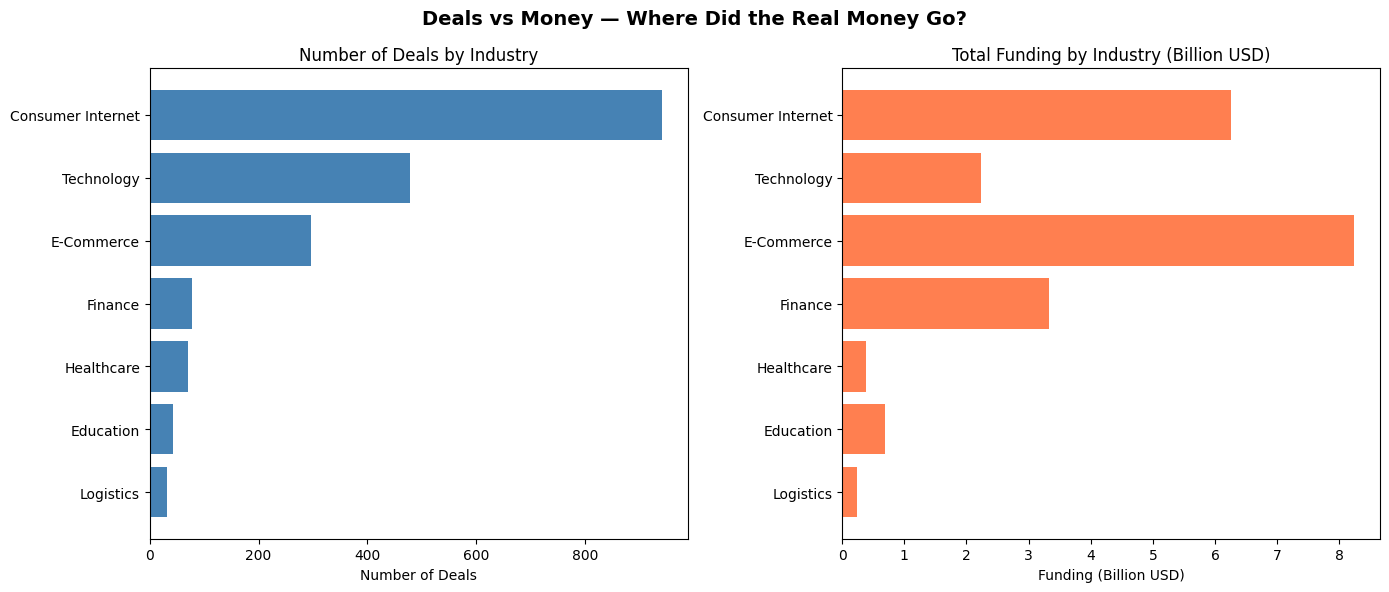

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Deals vs Money — Where Did the Real Money Go?', fontsize=14, fontweight='bold')

top_industries = industry_summary.head(7)

# Left - number of deals
axes[0].barh(top_industries.index[::-1], top_industries['total_deals'][::-1], color='steelblue')
axes[0].set_title('Number of Deals by Industry')
axes[0].set_xlabel('Number of Deals')

# Right - total funding
axes[1].barh(top_industries.index[::-1], top_industries['total_funding'][::-1] / 1e9, color='coral')
axes[1].set_title('Total Funding by Industry (Billion USD)')
axes[1].set_xlabel('Funding (Billion USD)')

plt.tight_layout()
plt.savefig('deals_vs_money.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Top investors by number of deals
top_investors = df['Investors Name'].value_counts().head(10)
print("Most active investors:")
print(top_investors)

# Seed vs Growth stage breakdown
stage_map = {
    'Seed Funding': 'Early Stage',
    'Angel Funding': 'Early Stage',
    'Series A': 'Growth Stage',
    'Series B': 'Growth Stage',
    'Series C': 'Growth Stage',
    'Series D': 'Growth Stage',
    'Private Equity': 'Late Stage',
    'Debt Funding': 'Late Stage'
}

df['Stage'] = df['InvestmentnType'].map(stage_map)
stage_summary = df.groupby('Stage').agg(
    deals=('Startup Name', 'count'),
    total_funding=('Amount in USD', 'sum')
).dropna()

print("\nStage breakdown:")
print(stage_summary)

Most active investors:
Investors Name
Undisclosed Investors       39
Undisclosed investors       30
Ratan Tata                  25
Indian Angel Network        23
Kalaari Capital             16
Sequoia Capital             15
Group of Angel Investors    15
Undisclosed Investor        12
Accel Partners              12
Brand Capital               11
Name: count, dtype: int64

Stage breakdown:
              deals  total_funding
Stage                             
Early Stage    1502   8.899581e+08
Growth Stage     69   3.628913e+09
Late Stage     1386   2.829924e+10


In [17]:
# Fix undisclosed investors
df['Investors Name'] = df['Investors Name'].replace({
    'Undisclosed Investors': 'Undisclosed',
    'Undisclosed investors': 'Undisclosed',
    'Undisclosed Investor': 'Undisclosed'
})

top_investors = df['Investors Name'].value_counts()
# Remove undisclosed and show real investors
real_investors = top_investors[top_investors.index != 'Undisclosed'].head(10)
print(real_investors)

Investors Name
Ratan Tata                  25
Indian Angel Network        23
Kalaari Capital             16
Sequoia Capital             15
Group of Angel Investors    15
Accel Partners              12
Brand Capital               11
Venture Catalysts           11
undisclosed investors       11
SAIF Partners               10
Name: count, dtype: int64


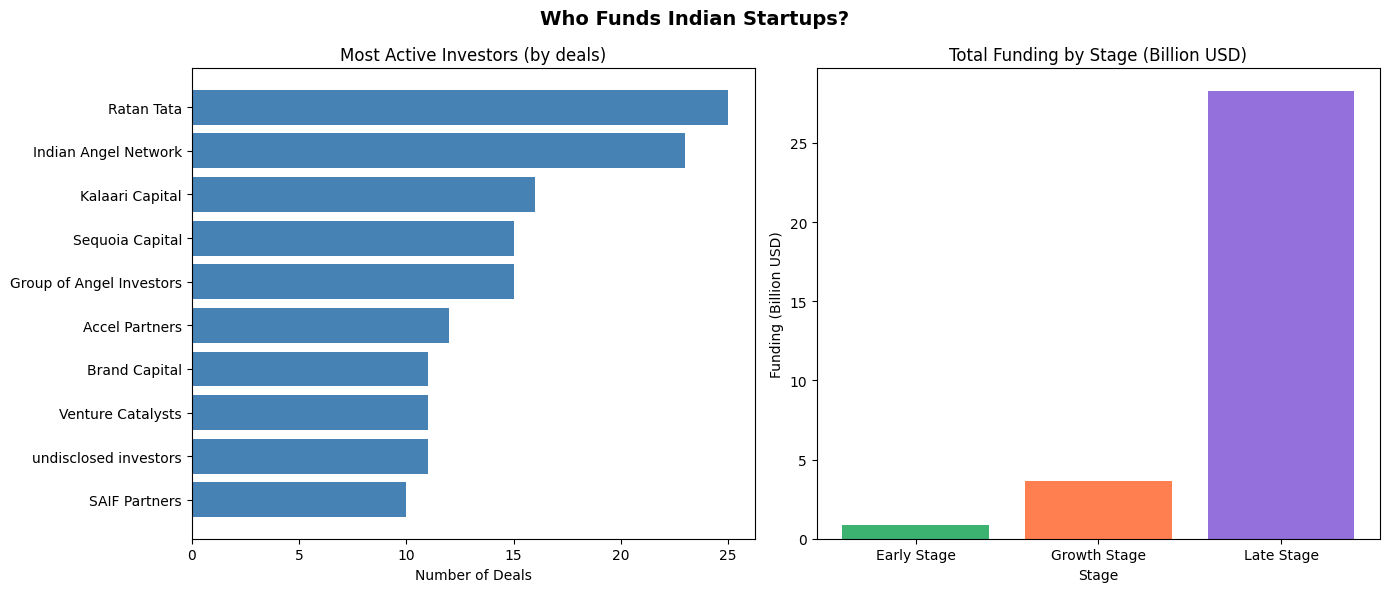

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Who Funds Indian Startups?', fontsize=14, fontweight='bold')

# Left - top real investors
axes[0].barh(real_investors.index[::-1], real_investors.values[::-1], color='steelblue')
axes[0].set_title('Most Active Investors (by deals)')
axes[0].set_xlabel('Number of Deals')

# Right - stage breakdown by funding
axes[1].bar(stage_summary.index, stage_summary['total_funding'] / 1e9, 
            color=['mediumseagreen', 'coral', 'mediumpurple'])
axes[1].set_title('Total Funding by Stage (Billion USD)')
axes[1].set_xlabel('Stage')
axes[1].set_ylabel('Funding (Billion USD)')

plt.tight_layout()
plt.savefig('investors_and_stages.png', dpi=150, bbox_inches='tight')
plt.show()

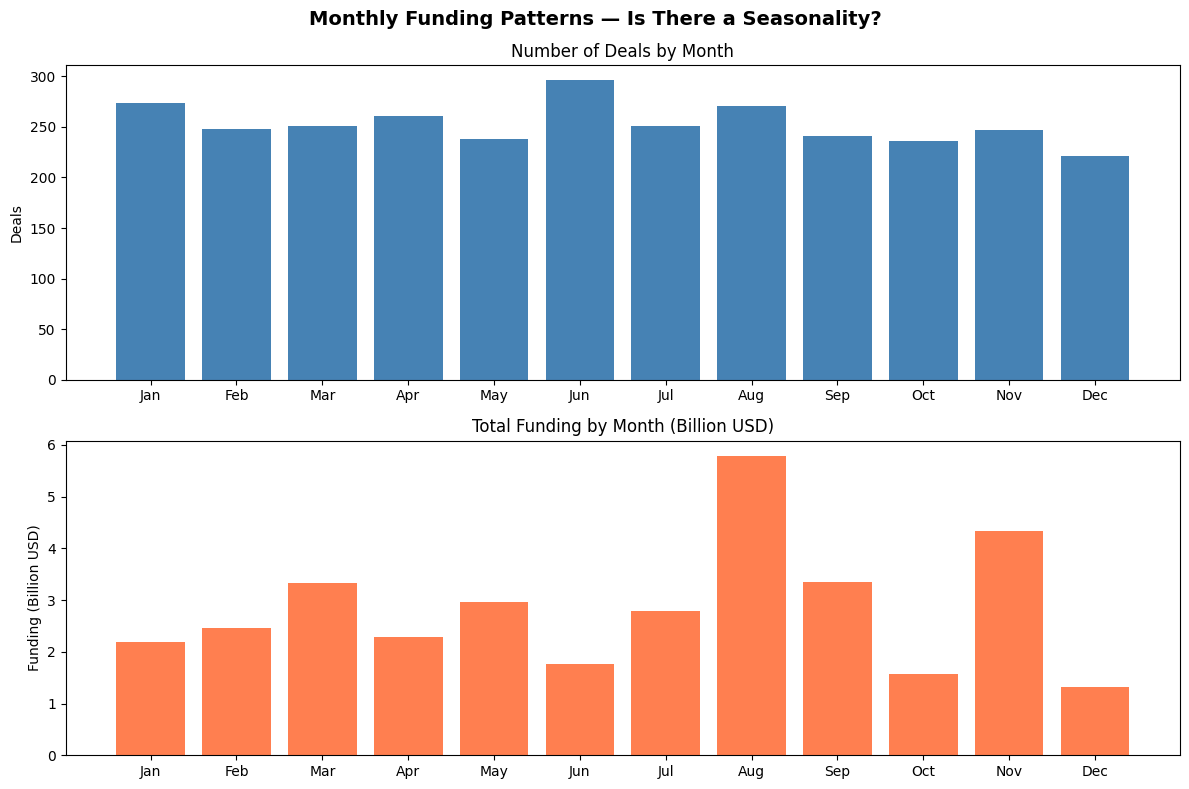

In [19]:
# Month wise deals and funding
monthly = df.groupby(['Year', 'Month']).agg(
    deals=('Startup Name', 'count'),
    funding=('Amount in USD', 'sum')
).reset_index()

# Overall month wise pattern across all years
monthly_pattern = df.groupby('Month').agg(
    deals=('Startup Name', 'count'),
    funding=('Amount in USD', 'sum')
).reset_index()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_pattern['Month Name'] = monthly_pattern['Month'].apply(
    lambda x: month_names[int(x)-1]
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle('Monthly Funding Patterns — Is There a Seasonality?', 
             fontsize=14, fontweight='bold')

axes[0].bar(monthly_pattern['Month Name'], 
            monthly_pattern['deals'], color='steelblue')
axes[0].set_title('Number of Deals by Month')
axes[0].set_ylabel('Deals')

axes[1].bar(monthly_pattern['Month Name'], 
            monthly_pattern['funding'] / 1e9, color='coral')
axes[1].set_title('Total Funding by Month (Billion USD)')
axes[1].set_ylabel('Funding (Billion USD)')

plt.tight_layout()
plt.savefig('monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()

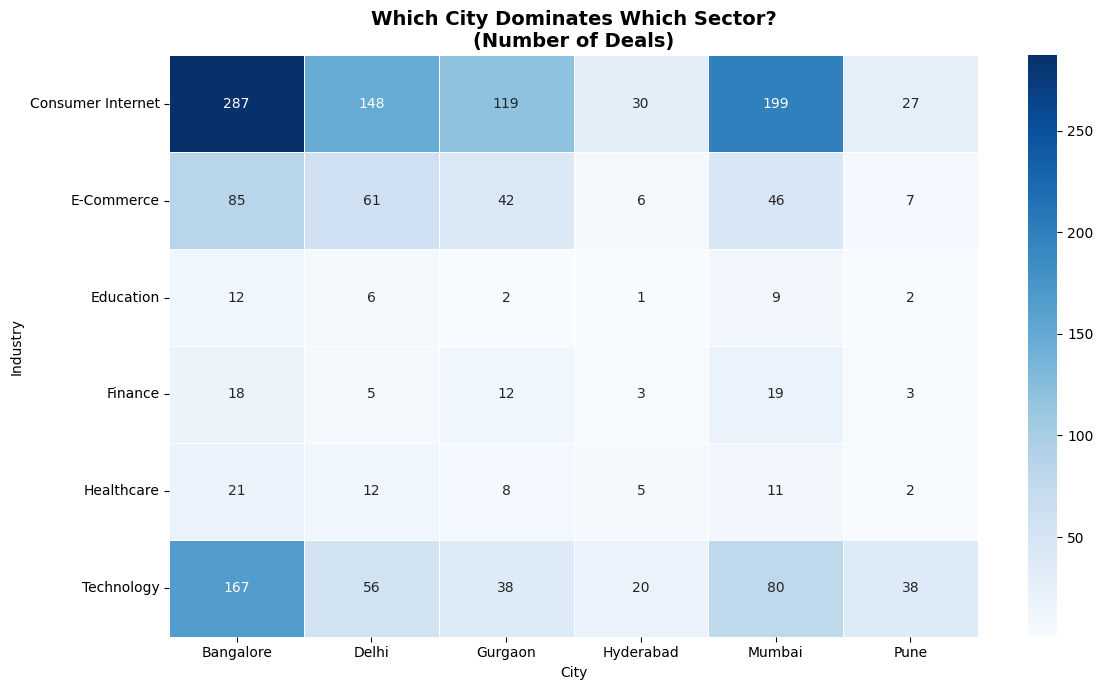

In [20]:
import seaborn as sns

# Top 6 cities and top 6 industries only
top_cities_list = ['Bangalore', 'Mumbai', 'Delhi', 'Gurgaon', 'Pune', 'Hyderabad']
top_industry_list = ['Consumer Internet', 'Technology', 'E-Commerce', 
                     'Finance', 'Healthcare', 'Education']

heatmap_data = df[
    df['City  Location'].isin(top_cities_list) & 
    df['Industry Vertical'].isin(top_industry_list)
]

pivot = heatmap_data.pivot_table(
    values='Startup Name',
    index='Industry Vertical',
    columns='City  Location',
    aggfunc='count',
    fill_value=0
)

plt.figure(figsize=(12, 7))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Which City Dominates Which Sector?\n(Number of Deals)', 
          fontsize=14, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Industry')
plt.tight_layout()
plt.savefig('city_industry_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

InvestmentnType
Seed Funding    1500
Series A          24
Series B          19
Series C          14
Series D          12
Name: count, dtype: int64


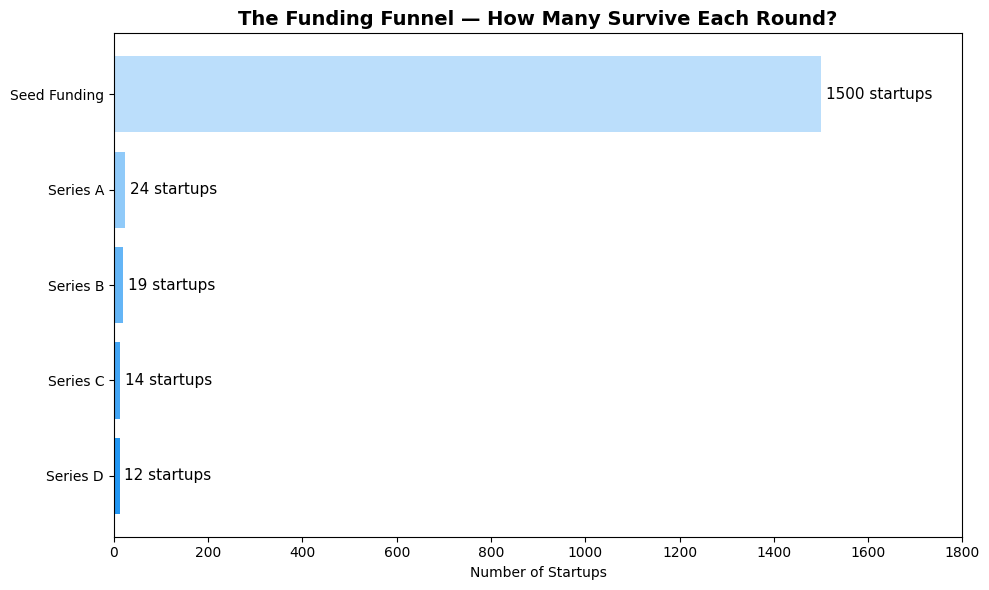

In [21]:
# Funnel - how many make it through each stage
funnel_stages = ['Seed Funding', 'Series A', 'Series B', 'Series C', 'Series D']
funnel_counts = df[df['InvestmentnType'].isin(funnel_stages)]['InvestmentnType'].value_counts()
funnel_counts = funnel_counts.reindex(funnel_stages).fillna(0)

print(funnel_counts)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(funnel_stages[::-1], funnel_counts.values[::-1], 
               color=['#2196F3','#42A5F5','#64B5F6','#90CAF9','#BBDEFB'])

# Add value labels
for bar, val in zip(bars, funnel_counts.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{int(val)} startups', va='center', fontsize=11)

ax.set_title('The Funding Funnel — How Many Survive Each Round?',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Startups')
ax.set_xlim(0, 1800)
plt.tight_layout()
plt.savefig('funding_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

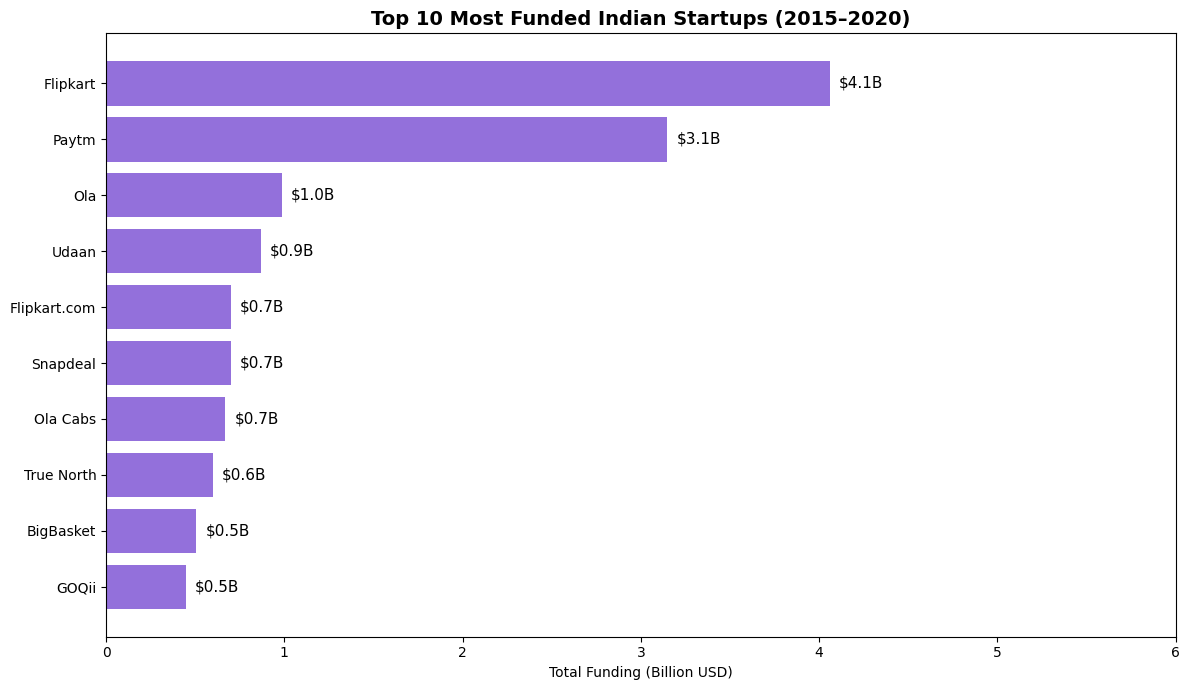

     Startup  Total Funding (B)
    Flipkart            4.05970
       Paytm            3.14895
         Ola            0.98450
       Udaan            0.87000
Flipkart.com            0.70000
    Snapdeal            0.70000
    Ola Cabs            0.66970
  True North            0.60000
   BigBasket            0.50700
       GOQii            0.45000


In [22]:
# Top 10 most funded startups
top_startups = df.groupby('Startup Name')['Amount in USD'].sum().sort_values(ascending=False).head(10).reset_index()
top_startups.columns = ['Startup', 'Total Funding']
top_startups['Total Funding (B)'] = top_startups['Total Funding'] / 1e9

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_startups['Startup'][::-1], 
               top_startups['Total Funding (B)'][::-1], 
               color='mediumpurple')

# Add value labels
for bar, val in zip(bars, top_startups['Total Funding (B)'][::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'${val:.1f}B', va='center', fontsize=11)

ax.set_title('Top 10 Most Funded Indian Startups (2015–2020)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Total Funding (Billion USD)')
ax.set_xlim(0, 6)
plt.tight_layout()
plt.savefig('top_startups.png', dpi=150, bbox_inches='tight')
plt.show()

print(top_startups[['Startup', 'Total Funding (B)']].to_string(index=False))